# Bai Tap Ve Nha - CNN phan loai Cat va Dog
- Mo hinh thuan CNN, khong dung pre-train
- Chong Overfitting: Dropout, BatchNorm
- Data Augmentation day du
- Muc tieu: Accuracy > 90%

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
import os, glob
from PIL import Image

# Tham so
IMG_SIZE = 150
BATCH = 32
EPOCHS = 30
DATA_DIR = './data/Data Cat and Dog'

# Loc anh bi hong truoc khi train
print('Dang kiem tra anh bi hong...')
bad = []
for f in glob.glob(os.path.join(DATA_DIR, '**', '*.*'), recursive=True):
    try:
        img = Image.open(f)
        img.verify()
    except:
        bad.append(f)
        os.remove(f)
print(f'Da xoa {len(bad)} anh bi hong:', bad if bad else 'Khong co')

# Augmentation cho tap train
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Tap test chi resize va chuan hoa
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Doc toan bo anh tu thu muc
full_data = torchvision.datasets.ImageFolder(DATA_DIR, transform=train_tf)
print('Classes:', full_data.classes, '| Tong anh:', len(full_data))

# Chia 80% train, 20% test
train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size
trainset, testset = random_split(full_data, [train_size, test_size])

# Ap transform khac cho test (khong augment)
testset.dataset = torchvision.datasets.ImageFolder(DATA_DIR, transform=test_tf)

# num_workers=0 de tranh loi multiprocessing tren Windows
trainloader = DataLoader(trainset, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
testloader = DataLoader(testset, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {train_size} | Test: {test_size}')

Dang kiem tra anh bi hong...


c:\Users\duong\AppData\Roaming\uv\python\cpython-3.9.25-windows-x86_64-none\lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Da xoa 0 anh bi hong: Khong co
Classes: ['Cat', 'Dog'] | Tong anh: 24998
Train: 19998 | Test: 5000


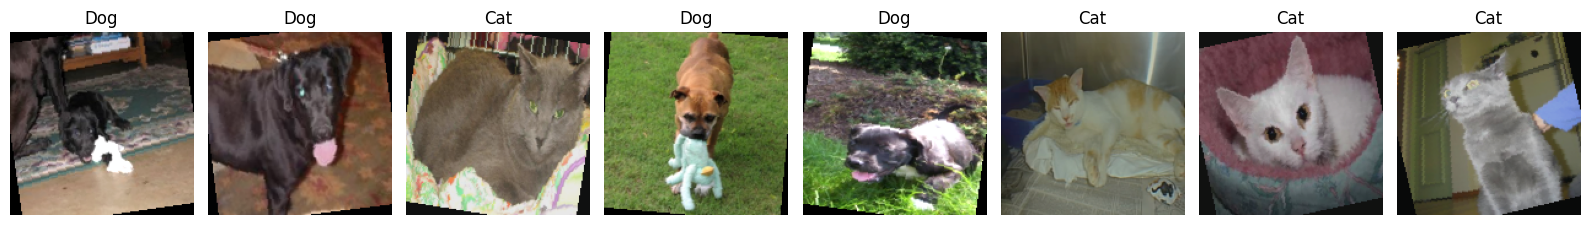

In [3]:
# Hien thi vài anh mau
imgs, labels = next(iter(trainloader))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    img = imgs[i].numpy().transpose(1, 2, 0) * std + mean
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(full_data.classes[labels[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Mo hinh CNN tu thiet ke
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Khoi conv 1: 3 kenh RGB -> 32 filter
        self.b1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # Khoi conv 2: 32 -> 64 filter
        self.b2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # Khoi conv 3: 64 -> 128 filter
        self.b3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # Khoi conv 4: 128 -> 256 filter
        self.b4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # Fully connected: phan loai 2 lop Cat/Dog
        p = IMG_SIZE // 16  # 4 lan MaxPool giam kich thuoc 16 lan
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * p * p, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 2))

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        return self.fc(x)

model = CatDogCNN().to(device)
print(f'Tong tham so: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Tong tham so: 11,793,570
CatDogCNN(
  (b1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (b2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

In [5]:
criterion = nn.CrossEntropyLoss()                                    # ham mat mat
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Adam + L2
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3) # giam LR khi acc khong tang

In [6]:
# Huan luyen
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    t_loss = loss_sum / len(trainloader)
    t_acc = 100 * correct / total

    # --- Danh gia test ---
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss_sum += criterion(out, labels).item()
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
    v_loss = loss_sum / len(testloader)
    v_acc = 100 * correct / total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    tag = ''
    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'best_catdog.pth') # luu model tot nhat
        tag = ' *'

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | T_Loss: {t_loss:.4f} T_Acc: {t_acc:.1f}% | V_Loss: {v_loss:.4f} V_Acc: {v_acc:.1f}%{tag}')
    scheduler.step(v_acc)

print(f'\nBest Accuracy: {best_acc:.2f}%')
model.load_state_dict(torch.load('best_catdog.pth')) # tai lai model tot nhat

Epoch  1/30 | T_Loss: 0.6713 T_Acc: 61.1% | V_Loss: 0.6166 V_Acc: 66.1% *
Epoch  2/30 | T_Loss: 0.5893 T_Acc: 68.3% | V_Loss: 0.4942 V_Acc: 75.6% *
Epoch  3/30 | T_Loss: 0.5371 T_Acc: 72.7% | V_Loss: 0.4763 V_Acc: 76.6% *
Epoch  4/30 | T_Loss: 0.4935 T_Acc: 76.0% | V_Loss: 0.4308 V_Acc: 80.4% *
Epoch  5/30 | T_Loss: 0.4640 T_Acc: 78.0% | V_Loss: 0.3702 V_Acc: 83.7% *
Epoch  6/30 | T_Loss: 0.4288 T_Acc: 80.1% | V_Loss: 0.3305 V_Acc: 85.5% *
Epoch  7/30 | T_Loss: 0.3893 T_Acc: 82.4% | V_Loss: 0.3031 V_Acc: 87.0% *
Epoch  8/30 | T_Loss: 0.3576 T_Acc: 84.0% | V_Loss: 0.2683 V_Acc: 88.9% *
Epoch  9/30 | T_Loss: 0.3324 T_Acc: 85.5% | V_Loss: 0.2594 V_Acc: 89.0% *
Epoch 10/30 | T_Loss: 0.3042 T_Acc: 86.6% | V_Loss: 0.2036 V_Acc: 91.7% *
Epoch 11/30 | T_Loss: 0.2844 T_Acc: 87.9% | V_Loss: 0.1903 V_Acc: 91.8% *
Epoch 12/30 | T_Loss: 0.2744 T_Acc: 88.3% | V_Loss: 0.1783 V_Acc: 92.6% *
Epoch 13/30 | T_Loss: 0.2576 T_Acc: 88.9% | V_Loss: 0.1961 V_Acc: 91.6%
Epoch 14/30 | T_Loss: 0.2456 T_Acc: 89.4

<All keys matched successfully>

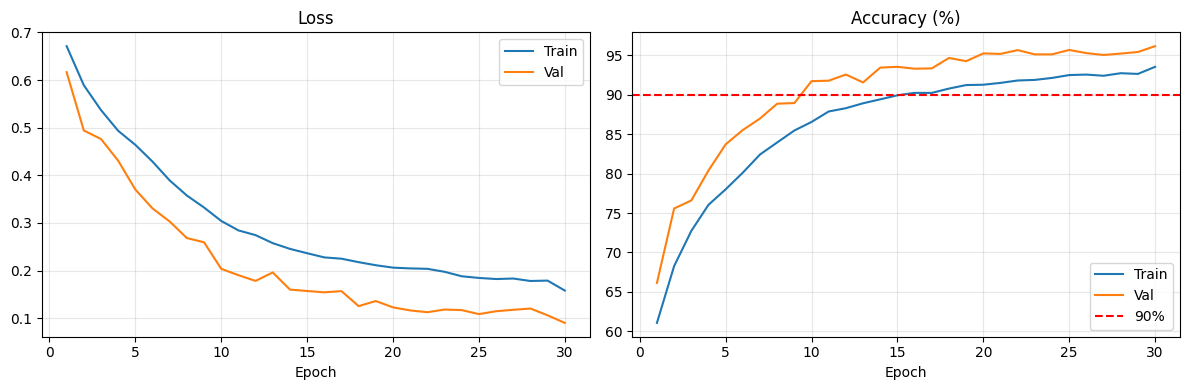

In [7]:
# Bieu do Loss va Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss']) + 1)

ax1.plot(ep, history['train_loss'], label='Train')
ax1.plot(ep, history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history['train_acc'], label='Train')
ax2.plot(ep, history['val_acc'], label='Val')
ax2.axhline(90, color='r', linestyle='--', label='90%')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Danh gia tung class
model.eval()
class_ok = [0, 0]
class_total = [0, 0]

with torch.no_grad():
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        for i in range(labels.size(0)):
            lb = labels[i].item()
            class_ok[lb] += (preds[i] == lb).item()
            class_total[lb] += 1

total_acc = 100 * sum(class_ok) / sum(class_total)
print(f'Tong Accuracy: {total_acc:.2f}%')
for i, name in enumerate(full_data.classes):
    print(f'  {name}: {100*class_ok[i]/class_total[i]:.2f}% ({class_ok[i]}/{class_total[i]})')

Tong Accuracy: 96.18%
  Cat: 94.93% (2342/2467)
  Dog: 97.39% (2467/2533)


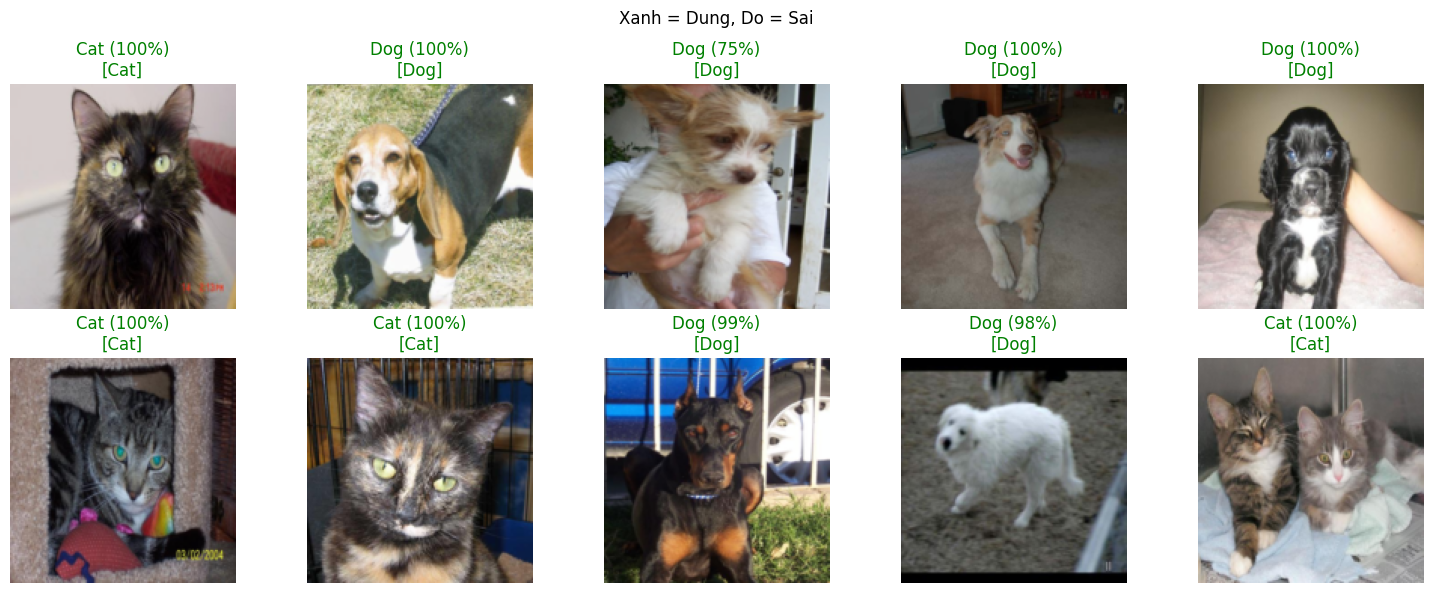

In [9]:
# Du doan thu 10 anh
model.eval()
imgs, labels = next(iter(testloader))
with torch.no_grad():
    probs = torch.softmax(model(imgs.to(device)), 1)
    preds = probs.argmax(1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = imgs[i].numpy().transpose(1, 2, 0) * std + mean
    ax.imshow(np.clip(img, 0, 1))
    p = full_data.classes[preds[i]]
    t = full_data.classes[labels[i]]
    c = probs[i][preds[i]].item() * 100
    ax.set_title(f'{p} ({c:.0f}%)\n[{t}]', color='green' if p == t else 'red')
    ax.axis('off')
plt.suptitle('Xanh = Dung, Do = Sai')
plt.tight_layout()
plt.show()